In [2]:
import pandas as pd
import numpy as np
from transformers import pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import time

# Initialize the Zero-Shot Classifier
# This matches the MODEL_ID used in your aiCategorizer.js
classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [14]:
# Define labels exactly as they appear in your transaction.model.js
EXPENSE_LABELS = [
    'Software & Subscriptions', 'Internet & Utilities', 'Hardware & Equipment',
    'Marketing & Advertising', 'Office Supplies', 'Education & Training',
    'Legal & Professional Fees', 'Travel', 'Meals & Entertainment', 'Rent or Lease'
]

INCOME_LABELS = [
    'Freelance Project', 'Hourly Wage', 'Retainer Fee',
    'Refund / Reimbursement', 'Passive Income', 'Other Income'
]

ALL_LABELS = EXPENSE_LABELS + INCOME_LABELS

In [15]:
def evaluate_categorizer(csv_path):
    # Load the substantial dataset
    df = pd.read_csv(csv_path)

    y_true = []
    y_pred = []

    print(f"Starting evaluation on {len(df)} transactions...")
    start_time = time.time()

    for index, row in df.iterrows():
        # Select candidate labels based on transaction type (credit/debit)
        # Matches the logic in your aiCategorizer.js [cite: 1791]
        candidates = INCOME_LABELS if row['type'] == 'credit' else EXPENSE_LABELS

        # Inference
        result = classifier(row['description'], candidate_labels=candidates)
        prediction = result['labels'][0]

        y_true.append(row['true_label'])
        y_pred.append(prediction)

        if (index + 1) % 10 == 0:
            print(f"Processed {index + 1}/{len(df)} samples...")

    end_time = time.time()
    print(f"Evaluation complete in {round(end_time - start_time, 2)} seconds.")

    return y_true, y_pred

# Run evaluation (Ensure 'test_transactions.csv' is in the same directory)
y_true, y_pred = evaluate_categorizer('test_transactions.csv')

Starting evaluation on 100 transactions...
Processed 10/100 samples...
Processed 20/100 samples...
Processed 30/100 samples...
Processed 40/100 samples...
Processed 50/100 samples...
Processed 60/100 samples...
Processed 70/100 samples...
Processed 80/100 samples...
Processed 90/100 samples...
Processed 100/100 samples...
Evaluation complete in 421.91 seconds.



CLASSIFICATION REPORT
                           precision    recall  f1-score   support

     Education & Training       1.00      0.40      0.57         5
        Freelance Project       1.00      0.12      0.22         8
     Hardware & Equipment       1.00      0.67      0.80        12
              Hourly Wage       1.00      0.60      0.75         5
     Internet & Utilities       1.00      0.33      0.50         6
Legal & Professional Fees       1.00      0.67      0.80         6
  Marketing & Advertising       0.50      0.60      0.55         5
    Meals & Entertainment       1.00      0.80      0.89         5
          Office Supplies       0.29      0.67      0.40         3
             Other Income       0.50      0.33      0.40         3
           Passive Income       0.44      0.80      0.57         5
   Refund / Reimbursement       0.57      1.00      0.73         4
            Rent or Lease       0.17      0.60      0.26         5
             Retainer Fee       0.25  

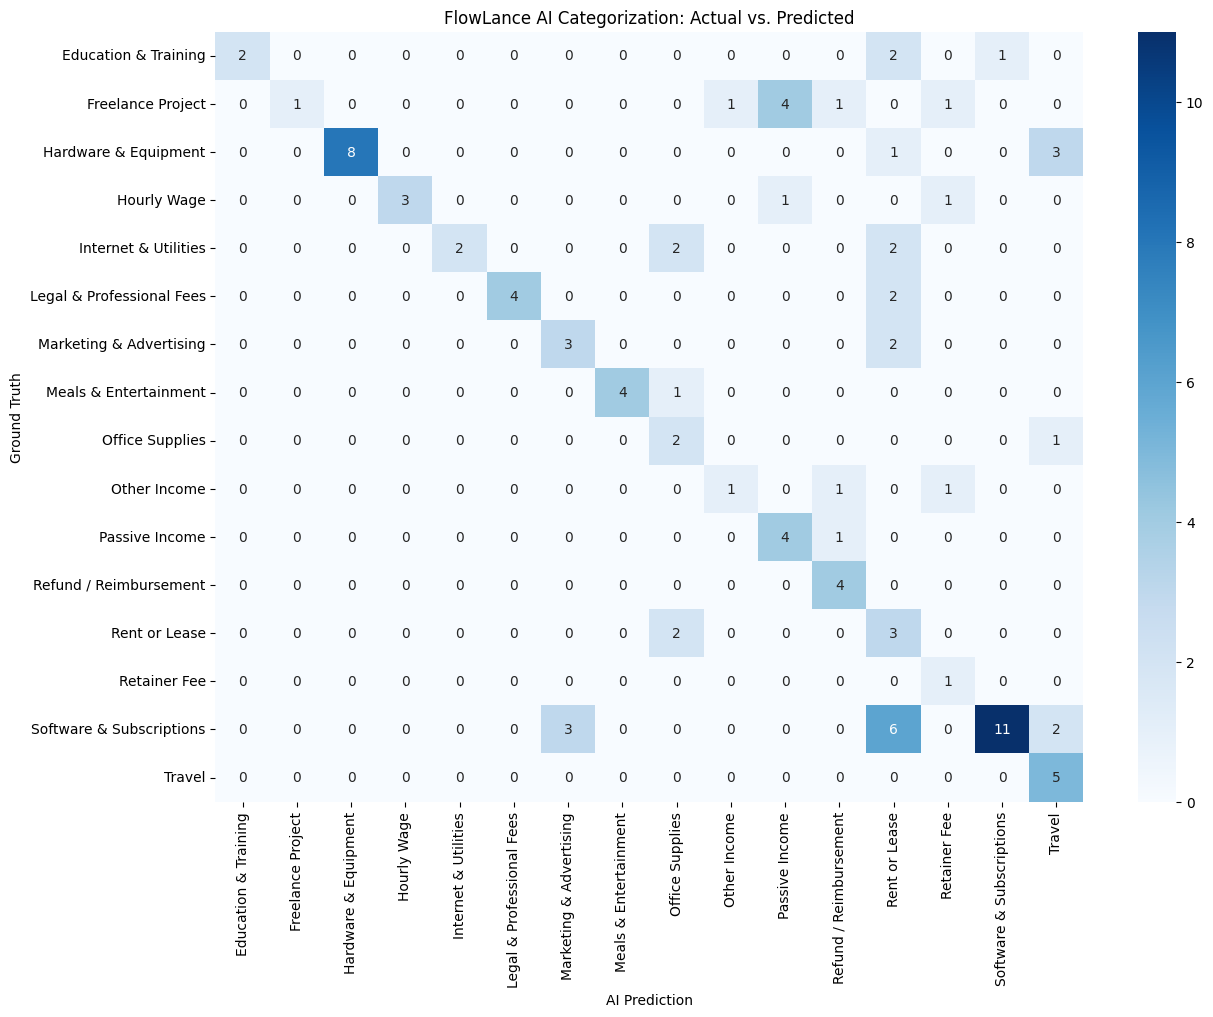

In [16]:
def display_results(y_true, y_pred):
    # Calculate Metrics
    print("\n" + "="*30)
    print("CLASSIFICATION REPORT")
    print("="*30)
    print(classification_report(y_true, y_pred, zero_division=0))

    print(f"Overall Accuracy: {round(accuracy_score(y_true, y_pred) * 100, 2)}%")

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred, labels=np.unique(y_true))
    plt.figure(figsize=(14, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=np.unique(y_true),
                yticklabels=np.unique(y_true))
    plt.title("FlowLance AI Categorization: Actual vs. Predicted")
    plt.ylabel('Ground Truth')
    plt.xlabel('AI Prediction')
    plt.show()

display_results(y_true, y_pred)